In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df1 = pd.read_csv("data/AllTopics.csv")
df2 = pd.read_csv("data/PostsForAnalysis.csv")
df3 = pd.read_csv("data/UsersForAnalysis.csv")

C:\Users\navee\AppData\Local\Temp\ipykernel_15728\4127935984.py:2: DtypeWarning: Columns (13,14,15,16,17,18,19,22,25,31,33,35,36,37,38,39,40,42,43,44,45,46,48,50,51,53,55,56,57,60,63,64,66,67,68,69,70,79,81,83,84,85,86,87,88,90,95,100,103,104,106,107,110,113,114,115,118,119,121,122,126,127,131,132,134,135,138,139,140,141,142,148,149,151,152,154,157,159,163,164,167,169,171,173,174,175,178,179,182,185,187,190,193,200,201,204,209,211,215,216,217,218,219,220,221,227,229,230,232,234,236,237,238,239,243,244,247,248,252,253,254,256,258,259,261,262,264,265,266,268,269,271,272,274,275,277,280,281,282,283,284,287,292,293,298,307,310,311,312) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("PostsForAnalysis.csv")


In [4]:
df2.isnull()

,id,date,day,created_at,time_of_day,name,tagline,thumbnail_type,product_state,comments_count,...,wi.fi,windows,wine,wordpress,writing.tools,xbox.one,yoga.books,youtube,user_id,votes_count
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18124,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
18125,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
18126,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
18127,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False


In [5]:
df2.fillna(0)

,id,date,day,created_at,time_of_day,name,tagline,thumbnail_type,product_state,comments_count,...,wi.fi,windows,wine,wordpress,writing.tools,xbox.one,yoga.books,youtube,user_id,votes_count
0,82423,2016-11-16,Wednesday,2016-11-16 00:20:00,Night,A.I. Experiments by Google,"Explore machine learning by playing w/ pics, m...",image,default,24,...,0,0,0,0,0,0,0,0,61044,1500
1,82480,2016-11-16,Wednesday,2016-11-16 05:40:53,Morning,Init.ai,Build powerful and intelligent conversational ...,image,default,43,...,0,0,0,0,0,0,0,0,1,802
2,82502,2016-11-16,Wednesday,2016-11-16 10:16:06,Morning,Google Earth VR,Walk the earth in VR,image,default,27,...,0,0,0,0,0,0,0,0,344208,544
3,82370,2016-11-16,Wednesday,2016-11-16 00:01:00,Night,Drop,Beautiful color picker with Touch Bar support,image,default,38,...,0,0,0,0,0,0,0,0,28756,446
4,82460,2016-11-16,Wednesday,2016-11-16 01:13:32,Night,Lookback Live,Real-time user research on mobile and desktop ...,image,default,25,...,0,0,0,0,0,0,0,0,591,416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18124,11419,2014-11-24,Monday,2014-11-24 06:12:53,Morning,Atomus,A utility library for testing client-side code...,image,default,1,...,0,0,0,0,0,0,0,0,8915,30
18125,11445,2014-11-24,Monday,2014-11-24 13:13:53,Afternoon,Funtionalize,Conductive 3D printing filament (pre-launch),image,default,1,...,0,0,0,0,0,0,0,0,851,14
18126,11434,2014-11-24,Monday,2014-11-24 09:37:24,Morning,ReapSo,Connect with your favorite brands and win prizes,image,default,2,...,0,0,0,0,0,0,0,0,16056,19
18127,11448,2014-11-24,Monday,2014-11-24 18:37:56,Evening,Staggering Beauty,Just wiggle it for a good time.,image,default,1,...,0,0,0,0,0,0,0,0,513,12


In [6]:
df4 = pd.concat([df1, df2, df3], axis=1)
df4.shape

(702611, 334)

<Axes: xlabel='posts_count', ylabel='votes_count'>

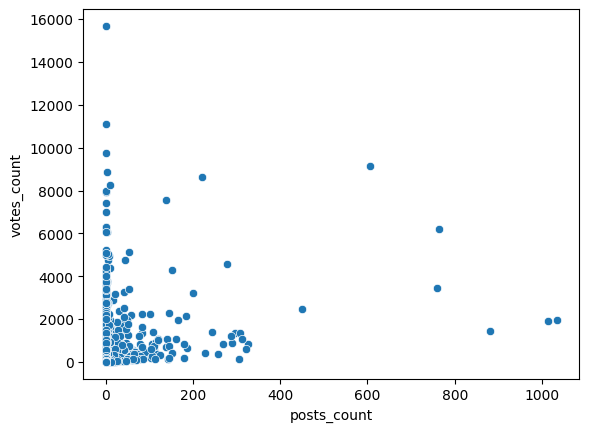

In [7]:
sns.scatterplot(x=df3["posts_count"], y=df3["votes_count"])

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [9]:
x = df3[["posts_count"]]
y = df3[["votes_count"]]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=325)

In [11]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
log_model = LogisticRegression(solver="saga", multi_class="ovr", max_iter=1000)

In [13]:
x = df2.drop("num_makers", axis=1)
y = df2["num_makers"]

In [14]:
a = np.array(y).shape
b = np.array(y).shape

In [15]:
x_train_, x_test_, y_train_, y_test_ = train_test_split(x, y, test_size=0.5, random_state=325)

In [16]:
a

(18129,)

In [17]:
b

(18129,)

In [18]:
scaler1 = StandardScaler()
x_train_ = scaler1.fit_transform(x_train_)
x_test_ = scaler1.transform(x_test_)

ValueError: could not convert string to float: '2016-10-08'

In [ ]:
log_model.fit(x_train_, y_train_)

ValueError: Expected 2D array, got 1D array instead:
array=[315.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.